In [21]:
import os
import sys
import yaml
import json
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
from IPython.display import display

from sklearn.metrics import roc_auc_score

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


## Extract genotype and phenotype data

In [22]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

def process_phenotypes_prs_long(
    gene_trait_df: pl.DataFrame,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
) -> pl.DataFrame:
    """
    Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
    """
    print("Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.")
    
    # --- Step 1: Unique phenotypes ---
    unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
    if not unique_phenotypes:
        raise ValueError("No phenotypes found in gene_trait_df")

    # --- Step 2: Read data lazily ---
    phenos_lazy = (
        pl.scan_parquet(pheno_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + unique_phenotypes)
        .drop_nulls()
    )

    prs_cols = [f"{pheno}_int_prs" for pheno in unique_phenotypes]
    prs_lazy = (
        pl.scan_parquet(prs_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + prs_cols)
        .drop_nulls()
    )

    cov_list = config.get("covariates", [])
    cov_lazy = (
        pl.scan_parquet(cov_path)
        .rename({'sample': 'individual'})
        .select(['individual'] + cov_list)
        .with_columns(pl.col('individual').cast(pl.Int64))
    )

    # --- Step 3: Merge all into one lazy DataFrame ---
    all_lazy = phenos_lazy.join(prs_lazy, on='individual', how='inner').join(
        cov_lazy, on='individual', how='inner'
    )
    
    # Collect once for regression computations (still needed for statsmodels)
    all_pd = all_lazy.collect().to_pandas()

    # --- Step 4: Compute residuals ---
    all_residuals_dfs = []

    for phenotype in unique_phenotypes:
        try:
            pheno_cols = [phenotype, f"{phenotype}_int_prs"] + cov_list
            temp_df = all_pd[['individual'] + pheno_cols].dropna()
            if len(temp_df) == 0:
                print(f"No data for phenotype: {phenotype}")
                continue

            y = temp_df[phenotype]
            X = temp_df.drop(columns=[phenotype, 'individual'])
            X = sm.add_constant(X)

            # model = sm.OLS(y, X).fit()
            # residuals = pd.Series(model.resid, index=temp_df.index, name=f"{phenotype}_residual")
            
            model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
            residuals = pd.Series(model.resid_deviance, index=temp_df.index, name=f"{phenotype}_residual")
            
            pheno_residuals = pd.concat([temp_df[['individual']], residuals], axis=1)
            all_residuals_dfs.append(pheno_residuals)

        except Exception as e:
            print(f"Error processing phenotype {phenotype}: {e}")
            continue

    if not all_residuals_dfs:
        raise ValueError("No residuals could be computed")

    # --- Step 5: Convert to long-format lazy DataFrame ---
    long_lazy_dfs = []
    for residual_df in all_residuals_dfs:
        p_wide_lazy = pl.LazyFrame(residual_df).with_columns(
            pl.col('individual').cast(pl.String)
        )
        pheno_cols = [c for c in residual_df.columns if c.endswith('_residual')]
        pdf_lazy = (
            p_wide_lazy.unpivot(
                index=['individual'],
                on=pheno_cols,
                variable_name='phenotype',
                value_name='pheno_value',
            )
            .with_columns(
                pl.col('phenotype').str.replace('_residual', '').alias('phenotype')
            )
        )
        long_lazy_dfs.append(pdf_lazy)

    combined_pdf_lazy = pl.concat(long_lazy_dfs) if len(long_lazy_dfs) > 1 else long_lazy_dfs[0]

    return combined_pdf_lazy.collect()


def process_gene_genotypes(
    gene_id: str, 
    regions_dict: dict, 
    sample_list: list
) -> pl.LazyFrame:
    """
    Extract genotypes for a specific gene and return as lazy DataFrame
    """
    try:
        reg_dict = regions_dict[gene_id]
        geno = reg_dict['genotypes']
        
        # Find heterozygous genotypes (genotype == 1)
        rows, cols = np.where(geno == 1)
        het = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 1
        })
        
        # Find homozygous genotypes (genotype == 2)
        rows, cols = np.where(geno == 2)
        hom = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 2
        })
        
        geno_melt_lazy = pl.concat([het, hom]).lazy().with_columns(
            pl.lit(gene_id).alias('region')
        )
        
        return geno_melt_lazy
        
    except Exception as e:
        print(f"Error processing genotypes for gene {gene_id}: {e}")
        return None


def get_geno_pheno(
    gene_trait_df: pl.DataFrame,
    anngeno_path: str,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    new_annotations_path: str,
    config: dict,
    prs_correction: bool = True,
    maf: float = None,
    eur_samples_path: str = None,
    only_missense_vars: bool = False,
    all_vars: bool = False,
):
    """
    Main processing pipeline for extracting the gene-phenotype data as one dataframe.
    """

    if prs_correction:
        # Process phenotypes (PRS + covariate correction)
        combined_pdf = process_phenotypes_prs_long(
            gene_trait_df,
            pheno_path,
            prs_path,
            cov_path,
            config,
        )
    else:
        unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
        combined_pdf = (
            pl.read_parquet(pheno_path)
            .rename({'IID': 'individual'})
            .select(['individual'] + unique_phenotypes)
            .drop_nulls()
            .unpivot(
                index=['individual'],
                on=unique_phenotypes,
                variable_name='phenotype',
                value_name='pheno_value',
            ).with_columns(
            pl.col('individual').cast(pl.String)
            )
        )
    
    # Convert to lazy for downstream processing
    combined_pdf_lazy = pl.LazyFrame(combined_pdf)

    # Initialize AnnGeno
    print("Loading AnnGeno...")
    ag = AnnGeno(anngeno_path, mode='r', low_mem=True)

    if maf:
        variants_to_keep = (
            ag.annotations.filter(pl.col('af_ukb') <= maf)
            .select('id')
            .collect()['id']
        )
        ag.subset_variants(set(variants_to_keep))

    eur_samples = None
    if eur_samples_path:
        eur_samples = pl.read_csv(eur_samples_path).with_columns(
            pl.col("eid").cast(pl.Utf8)
        )['eid'].to_list()
        ag.subset_samples(set(eur_samples))

    # Get regions
    unique_genes = gene_trait_df['gene_id'].unique().to_list()
    regions_dict = ag.get_many_regions(unique_genes)

    # Load new scores lazily
    new_anno = None
    if new_annotations_path:
        print("Adding new scores to benchmark...")
        new_anno = (
            pl.read_parquet(new_annotations_path)
            .filter(pl.col('region').is_in(unique_genes))
        )

    # Collect annotation categories
    all_annotation_list = []
    rare_variant_annotations_dict = config.get("rare_variant_annotations")
    if rare_variant_annotations_dict:
        for category in rare_variant_annotations_dict.values():
            all_annotation_list.extend(category)

    all_results_lazy = []
    pheno_gis_df = None  # last computed pheno_gis_df, useful when plotting for a single gene-trait pair

    gene_to_traits = (
        gene_trait_df.group_by("gene_id")
        .agg(pl.col("phenotype").unique().alias("phenotypes"))
    )

    gene_pheno_df_list = []

    # --- Loop by gene, compute genotypes once ---
    for row in tqdm(gene_to_traits.iter_rows(named=True), total=len(gene_to_traits)):
        gene_id = row["gene_id"]
        phenotypes = row["phenotypes"]

        print(f"Processing gene {gene_id} with {len(phenotypes)} phenotypes")

        geno_melt_lazy = process_gene_genotypes(gene_id, regions_dict, ag.samples)
        if geno_melt_lazy is None:
            print(f"No genotype data for {gene_id}")
            continue

        anno_df_lazy = pl.LazyFrame(regions_dict[gene_id]["annotations"])

        # Handle new annotations
        if new_annotations_path and new_anno is not None:
            new_anno_gene_lazy = (
                new_anno
                .filter(pl.col("region") == gene_id)
                .pivot(
                    index=['id', 'region', 'gene_name'],
                    on='assay_name',
                    values='score'
                )
                .drop_nulls()
                .lazy()
            )

        # --- Loop over phenotypes for this gene ---
        for phenotype in phenotypes:
            print(f" -> {gene_id} - {phenotype}")

            pheno_data_lazy = combined_pdf_lazy.filter(pl.col("phenotype") == phenotype)
            
            # Check if we have phenotype data before proceeding
            if pheno_data_lazy.select(pl.len()).collect().item() == 0:
                print(f"No phenotype data for {phenotype}")
                continue

            gp_lazy = geno_melt_lazy.join(pheno_data_lazy, on="individual")

            if eur_samples is not None:
                gp_lazy = gp_lazy.filter(pl.col("individual").is_in(eur_samples))

            gp_lazy = gp_lazy.filter(pl.col("genotype") == 1)
            
            # Check if we have valid data before proceeding
            if gp_lazy.select(pl.len()).collect().item() == 0:
                print(f"No valid genotype-phenotype data for {gene_id} - {phenotype}")
                continue

            # Prepare annotations
            if new_annotations_path and new_anno is not None:
                new_anno_gene_collected = new_anno_gene_lazy.collect()
                if 'id' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='id', how='inner')
                elif 'mutant' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='mutant', how='inner')
                else:
                    print(f"No matching column for joining new annotations for {gene_id}")
                    continue
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns)) + new_anno_gene_collected.columns[3:]
            else:
                anno_wide_lazy = anno_df_lazy
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns))

            if not available_annotations:
                print(f"No valid annotations for {gene_id}")
                continue

            if only_missense_vars:
                anno_wide_lazy = anno_wide_lazy.filter(pl.col('consequence_missense_variant') == 1)

            anno_melt_lazy = anno_wide_lazy.unpivot(
                index=['id', 'region', 'af_ukb'],
                on=available_annotations,
                variable_name='annotation',
                value_name='score',
            ).with_columns(
                score =pl.col('score').cast(pl.Float32)
            )

            ## Add all variant scores
            if all_vars:
                temp_anno_collected = anno_df_lazy.select(pl.all().head(1)).collect()
                annos_all_vars = list(set(all_annotation_list) & set(temp_anno_collected.columns))
                all_anno_melt_lazy = (
                    anno_df_lazy
                    .filter(pl.col('consequence_missense_variant') == 1)
                    .unpivot(
                        index=['id', 'region'],
                        on=annos_all_vars,
                        variable_name='annotation',
                        value_name='score',
                    )
                    .with_columns(
                        annotation = (pl.col('annotation') + "_allvars")
                    )
                )
                anno_melt_lazy = pl.concat([anno_melt_lazy, all_anno_melt_lazy])

            gpa_lazy = gp_lazy.join(anno_melt_lazy, on='id', how='inner')
            
            # Check if we have data after joining annotations
            if gpa_lazy.select(pl.len()).collect().item() == 0:
                print(f"No data after joining annotations for {gene_id} - {phenotype}")
                continue
            
            gene_pheno_df_list.append(gpa_lazy)
    
    gene_pheno_df = pl.concat(gene_pheno_df_list).collect(engine='streaming')
    return gene_pheno_df

In [23]:
# Configuration and paths
corr_method = 'spearman'
bootstrapping = False
trait_type = 'quantitative'
all_vars = False

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int_female.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
anngeno_path = '/home/dnanexus/data_dir/dms_coding.ag'

exp_data_path = '/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined.parquet'
save_path = None

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

gene_trait_df = pl.DataFrame({
    'gene_id': ["ENSG00000139618"], #BRCA2 ["ENSG00000012048"], #BRCA1
    'phenotype': ["jurgens_breast_cancer"]
})

pheno_gis_df = get_geno_pheno(
    gene_trait_df=gene_trait_df,
    anngeno_path=anngeno_path,
    pheno_path=pheno_path,
    prs_path=prs_path,
    cov_path=cov_path,
    new_annotations_path=exp_data_path,
    config=config,
    maf=maf,
    eur_samples_path=eur_samples_path,
    prs_correction=False,
    only_missense_vars=True,
    all_vars=all_vars,
)

pheno_gis_df

Loading AnnGeno...


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
100%|██████████| 490541/490541 [00:00<00:00, 2836261.63it/s]


Adding new scores to benchmark...


  0%|          | 0/1 [00:00<?, ?it/s]

Processing gene ENSG00000139618 with 1 phenotypes


100%|██████████| 1/1 [00:06<00:00,  6.34s/it]

 -> ENSG00000139618 - jurgens_breast_cancer


id,individual,genotype,region,phenotype,pheno_value,region_right,af_ukb,annotation,score
str,str,i32,str,str,f32,str,f32,str,f32
"""chr13:32380079:G:A""","""1034469""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000068,"""esmscoremissense""",-3.297
"""chr13:32380079:G:A""","""1034469""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000068,"""gpn_score""",-5.34
"""chr13:32380079:G:A""","""1034469""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000068,"""zooverphylop""",4.082
"""chr13:32380079:G:A""","""1034469""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000068,"""relative_cds_position""",0.9
"""chr13:32380079:G:A""","""1034469""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000068,"""cadd_raw""",2.836111
…,…,…,…,…,…,…,…,…,…
"""chr13:32394707:A:G""","""3632587""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000058,"""cadd_raw""",4.303872
"""chr13:32394707:A:G""","""3632587""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000058,"""am_pathogenicity""",0.2454
"""chr13:32394707:A:G""","""3632587""",1,"""ENSG00000139618""","""jurgens_breast_cancer""",0.0,"""ENSG00000139618""",0.000058,"""verphylop""",5.645


In [24]:
pheno_gis_df['id'].value_counts(sort=True)

id,count
str,u64
"""chr13:32379412:G:T""",3366
"""chr13:32363196:A:G""",2178
"""chr13:32356536:C:T""",936
"""chr13:32394724:T:C""",693
"""chr13:32379479:C:T""",486
…,…
"""chr13:32379468:T:C""",9
"""chr13:32356470:T:C""",9
"""chr13:32379327:G:A""",9


In [25]:
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
"""conservation""","""verphylop""","""#440154""","""Vertebrate PhyloP""",1
"""naive""","""relative_cds_position""","""#b5de2b""","""Relative CDS Position""",-1


In [26]:
pheno_gis_df.join(anno_config_df[['annotation', 'annotation_dir']], on='annotation').fill_null

<bound method DataFrame.fill_null of shape: (13_804, 11)
┌────────────┬────────────┬──────────┬───────────┬───┬──────────┬───────────┬──────────┬───────────┐
│ id         ┆ individual ┆ genotype ┆ region    ┆ … ┆ af_ukb   ┆ annotatio ┆ score    ┆ annotatio │
│ ---        ┆ ---        ┆ ---      ┆ ---       ┆   ┆ ---      ┆ n         ┆ ---      ┆ n_dir     │
│ str        ┆ str        ┆ i32      ┆ str       ┆   ┆ f32      ┆ ---       ┆ f32      ┆ ---       │
│            ┆            ┆          ┆           ┆   ┆          ┆ str       ┆          ┆ i64       │
╞════════════╪════════════╪══════════╪═══════════╪═══╪══════════╪═══════════╪══════════╪═══════════╡
│ chr13:3238 ┆ 1034469    ┆ 1        ┆ ENSG00000 ┆ … ┆ 0.000068 ┆ esmscorem ┆ -3.297   ┆ -1        │
│ 0079:G:A   ┆            ┆          ┆ 139618    ┆   ┆          ┆ issense   ┆          ┆           │
│ chr13:3238 ┆ 1034469    ┆ 1        ┆ ENSG00000 ┆ … ┆ 0.000068 ┆ gpn_score ┆ -5.34    ┆ -1        │
│ 0079:G:A   ┆            ┆       

## Compute AUC, correlation, etc.

In [ ]:
def bootstrap_samples(
    gpa_df: pl.DataFrame, 
    n_bootstraps: int, 
    seed: int = None,
    bootstrap_type: str = "samples"
) -> pl.LazyFrame:
    """
    Bootstrap samples or variants for correlation analysis - returns lazy frame
    """
    if seed is not None:
        np.random.seed(seed)

    if bootstrap_type == "samples":
        # Original sample bootstrapping
        unique_ids = gpa_df.select('individual').unique().to_series().to_list()
        n_ids = len(unique_ids)

        # Prepare all bootstrap samples
        sampled_ids = np.random.choice(unique_ids, size=(n_bootstraps, n_ids), replace=True)

        # Flatten and make DataFrame with bootstrap_id
        boot_id_col = np.repeat(np.arange(n_bootstraps), n_ids)
        sampled_flat = pl.LazyFrame({
            'bootstrap_id': boot_id_col,
            'individual': sampled_ids.ravel()
        })

        # Lazy join to replicate rows
        boot_df_lazy = sampled_flat.join(gpa_df.lazy(), on='individual', how='left')

    elif bootstrap_type == "variants":
        # Variant bootstrapping - resample variants instead of individuals
        unique_variants = gpa_df.select('id').unique().to_series().to_list()
        n_variants = len(unique_variants)

        # Prepare all bootstrap variant samples
        sampled_variants = np.random.choice(unique_variants, size=(n_bootstraps, n_variants), replace=True)

        # Flatten and make DataFrame with bootstrap_id
        boot_id_col = np.repeat(np.arange(n_bootstraps), n_variants)
        sampled_flat = pl.LazyFrame({
            'bootstrap_id': boot_id_col,
            'id': sampled_variants.ravel()
        })

        # Lazy join to replicate rows
        boot_df_lazy = sampled_flat.join(gpa_df.lazy(), on='id', how='left')

    else:
        raise ValueError("bootstrap_type must be 'samples' or 'variants'")

    # Group by bootstrap_id + original grouping columns - keep lazy
    pheno_gis_lazy = boot_df_lazy.select(
        ['bootstrap_id', 'id', 'individual', 'phenotype', 'region', 'annotation', 'pheno_value', 'score']
    ).drop_nulls(subset=['pheno_value', 'score'])

    return pheno_gis_lazy


def compute_bootstrap_auc(
    boot_df: pl.DataFrame,
    confidence_level: float = 0.95
) -> pl.DataFrame:
    """
    Compute bootstrap AUCs with confidence intervals.
    """
    # Compute AUC for each bootstrap sample × annotation
    auc_per_boot = (
        boot_df
        .group_by(['annotation', 'bootstrap_id'])
        .map_groups(lambda df: pl.DataFrame({
            "annotation": [df["annotation"][0]],
            "n_variants": [df['id'].n_unique()],
            "auc": [compute_auc(df)]
        }),
        schema={"annotation": pl.Utf8, "n_variants": pl.Int64, "auc": pl.Float64}
        )
    )

    alpha = 1 - confidence_level
    # Aggregate across bootstraps to get mean + CI
    auc_summary = (
        auc_per_boot
        .group_by('annotation')
        .agg([
            pl.mean('auc').alias('auc_mean'),
            pl.quantile('auc', alpha / 2).alias('auc_lower'),
            pl.quantile('auc', 1 - alpha / 2).alias('auc_upper'),
            pl.count('auc').alias('n_bootstraps')
        ])
    )

    return auc_summary

def compute_auc(df: pl.DataFrame) -> float:
    try:
        return roc_auc_score(df['pheno_value'], df['score'])
    except ValueError:  # e.g., only one class present
        return np.nan

In [ ]:
# --- Lazy AUC computation ---
    save_path: str = None,
    n_bootstraps: int = None,
    bootstrap_seed: int = None,
    confidence_level: float = 0.95,
    bootstrap_type: str = "samples",

            pheno_gis_lazy = gpa_lazy.select(
                ['id', 'individual', 'phenotype', 'region', 'annotation', 'pheno_value', 'score']
            ).drop_nulls(subset=['pheno_value', 'score'])
            
            # Check if we have aggregated data
            if pheno_gis_lazy.select(pl.len()).collect().item() == 0:
                continue

            auc_lazy = (
                pheno_gis_lazy
                .group_by(['annotation', 'phenotype', 'region'])
                .map_groups(lambda df: pl.DataFrame({
                    "annotation": [df["annotation"][0]],
                    "phenotype": [df["phenotype"][0]],
                    "region": [df["region"][0]],
                    "auc": [compute_auc(df)],
                    "n_variants": [df['id'].n_unique()]
                    }),
                    schema={"auc": pl.Float64, "n_variants": pl.Int64}
                )
                .drop_nulls(subset=['auc'])
                .sort('auc', descending=True)
            )

            # Bootstrap analysis
            if n_bootstraps and n_bootstraps > 0:
                # Collect gpa_df for bootstrapping (needed for numpy operations)
                gpa_collected = gpa_lazy.collect()
                
                if len(gpa_collected) == 0:
                    print(f"No data for bootstrapping {gene_id} - {phenotype}")
                    continue
                
                # Generate bootstrap samples
                boot_pheno_gis_lazy = bootstrap_samples(
                    gpa_collected, 
                    n_bootstraps, 
                    seed=bootstrap_seed,
                    bootstrap_type=bootstrap_type
                )
                
                # Compute bootstrap correlations
                boot_auc_lazy = compute_bootstrap_auc(
                    boot_pheno_gis_lazy,
                    confidence_level
                ).with_columns([
                    pl.lit(bootstrap_type).alias('bootstrap_type'),
                ])

                auc_lazy = auc_lazy.join(boot_auc_lazy, on=['annotation'], how='full')

            # all_results_lazy.append(corr_lazy)
            all_results_lazy.append(auc_lazy)

            # Store the last pheno_gis for plotting (collect only when needed)
            pheno_gis_df = pheno_gis_lazy.collect()
    
    # Combine results lazily and collect at the end
    if all_results_lazy:
        final_corr_lazy = pl.concat(all_results_lazy)
        final_corr_df = final_corr_lazy.collect()
        print(f"Final correlation results shape: {final_corr_df.shape}")
        
        if save_path:
            final_corr_lazy.sink_parquet(f'{save_path}/multi_gene_trait_correlations.parquet')
    else:
        final_corr_df = pl.DataFrame()

    return pheno_gis_df, final_corr_df

# Old Code

## Run code

### Define params

In [3]:
# a = pl.read_parquet('/home/dnanexus/data_dir/exp_data/BRCA1_SGE_Dace2025.parquet')
# b = pl.read_parquet('/home/dnanexus/data_dir/exp_data/BRCA1_SGE_Findlay2018.parquet')
# c = pl.read_parquet('/home/dnanexus/data_dir/exp_data/BRCA2_SGE_Huang2025.parquet')
# d = pl.read_parquet('/home/dnanexus/data_dir/exp_data/BRCA2_SGE_Sahu2025.parquet')

# print(a.shape, b.shape, c.shape, d.shape)
# sge_df = pl.concat([a[c.columns], b[c.columns], c, d])
# sge_df.write_parquet('/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined.parquet')

In [9]:
# Configuration and paths
corr_method = 'spearman'
bootstrapping = False
trait_type = 'quantitative'
all_vars = False

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int_female.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
anngeno_path = '/home/dnanexus/data_dir/dms_coding.ag'

exp_data_path = '/home/dnanexus/data_dir/exp_data/BRCA1_BRCA2_SGE_combined.parquet'
save_path = None

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac

759.292

In [10]:
# c = pl.read_parquet(cov_path, columns=['sample', 'sex']).rename({'sample': 'IID'}).with_columns(pl.col('IID').cast(pl.Int32))

# p = pl.read_parquet(pheno_path)
# fp = c.join(p, on='IID').filter(pl.col('sex')==0)
# fp.write_parquet('/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int_female.parquet')

## Execute pipeline

In [11]:
gene_trait_df = pl.DataFrame({
    'gene_id': ["ENSG00000139618"], #BRCA2 ["ENSG00000012048"], #BRCA1
    'phenotype': ["jurgens_breast_cancer"]
})

unique_genes = gene_trait_df['gene_id'].unique().to_list()
unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()

In [12]:
pheno_gis_df, final_auc_df = auc_pipeline(
    gene_trait_df=gene_trait_df,
    anngeno_path=anngeno_path,
    pheno_path=pheno_path,
    prs_path=prs_path,
    cov_path=cov_path,
    new_annotations_path=exp_data_path,
    config=config,
    maf=maf,
    eur_samples_path=eur_samples_path,
    prs_correction=False,
    save_path=None,
    only_missense_vars=True,
    all_vars=all_vars,
    n_bootstraps=1000,
    bootstrap_seed=42,
    confidence_level=0.95,
    bootstrap_type="samples",
)

final_auc_df

Loading AnnGeno...


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
100%|██████████| 490541/490541 [00:00<00:00, 3082230.25it/s]


Adding new scores to benchmark...


  0%|          | 0/1 [00:00<?, ?it/s]

Processing gene ENSG00000139618 with 1 phenotypes
 -> ENSG00000139618 - jurgens_breast_cancer


100%|██████████| 1/1 [00:06<00:00,  6.97s/it]


ColumnNotFoundError: unable to find column "annotation"; valid columns: ["auc", "n_variants"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
 WITH_COLUMNS:
 ["samples".alias("bootstrap_type")] 
  AGGREGATE[maintain_order: false]
    [col("auc").mean().alias("auc_mean"), col("auc").quantile(0.025, interpolation='nearest').alias("auc_lower"), col("auc").quantile(0.975, interpolation='nearest').alias("auc_upper"), col("auc").count().alias("n_bootstraps")] BY [col("annotation")]
    FROM
    AGGREGATE[maintain_order: false]
      MAP_GROUPS BY [col("annotation"), col("bootstrap_id")]
      FROM
      FROM
      FILTER col("score").is_not_null()
      FROM
        FILTER col("pheno_value").is_not_null()
        FROM
          SELECT [col("bootstrap_id"), col("id"), col("individual"), col("phenotype"), col("region"), col("annotation"), col("pheno_value"), col("score")]
            LEFT JOIN:
            LEFT PLAN ON: [col("individual")]
              DF ["bootstrap_id

In [ ]:
pheno_gis_df

id,individual,phenotype,region,annotation,pheno_value,score
str,str,str,str,str,f32,f32
"""chr13:32363187:C:T""","""1001814""","""jurgens_breast_cancer""","""ENSG00000139618""","""relprotpos""",0.0,0.779
"""chr13:32363187:C:T""","""1001814""","""jurgens_breast_cancer""","""ENSG00000139618""","""relative_cds_position""",0.0,0.78
"""chr13:32363187:C:T""","""1001814""","""jurgens_breast_cancer""","""ENSG00000139618""","""am_pathogenicity""",0.0,0.0473
"""chr13:32363187:C:T""","""1001814""","""jurgens_breast_cancer""","""ENSG00000139618""","""verphylop""",0.0,6.593
"""chr13:32363187:C:T""","""1001814""","""jurgens_breast_cancer""","""ENSG00000139618""","""cadd_raw""",0.0,2.406657
…,…,…,…,…,…,…
"""chr13:32379479:C:T""","""6023206""","""jurgens_breast_cancer""","""ENSG00000139618""","""esmscoremissense""",0.0,-5.317
"""chr13:32379479:C:T""","""6023206""","""jurgens_breast_cancer""","""ENSG00000139618""","""zooverphylop""",0.0,5.868
"""chr13:32379479:C:T""","""6023206""","""jurgens_breast_cancer""","""ENSG00000139618""","""gpn_score""",0.0,-5.07


### Correlations plot

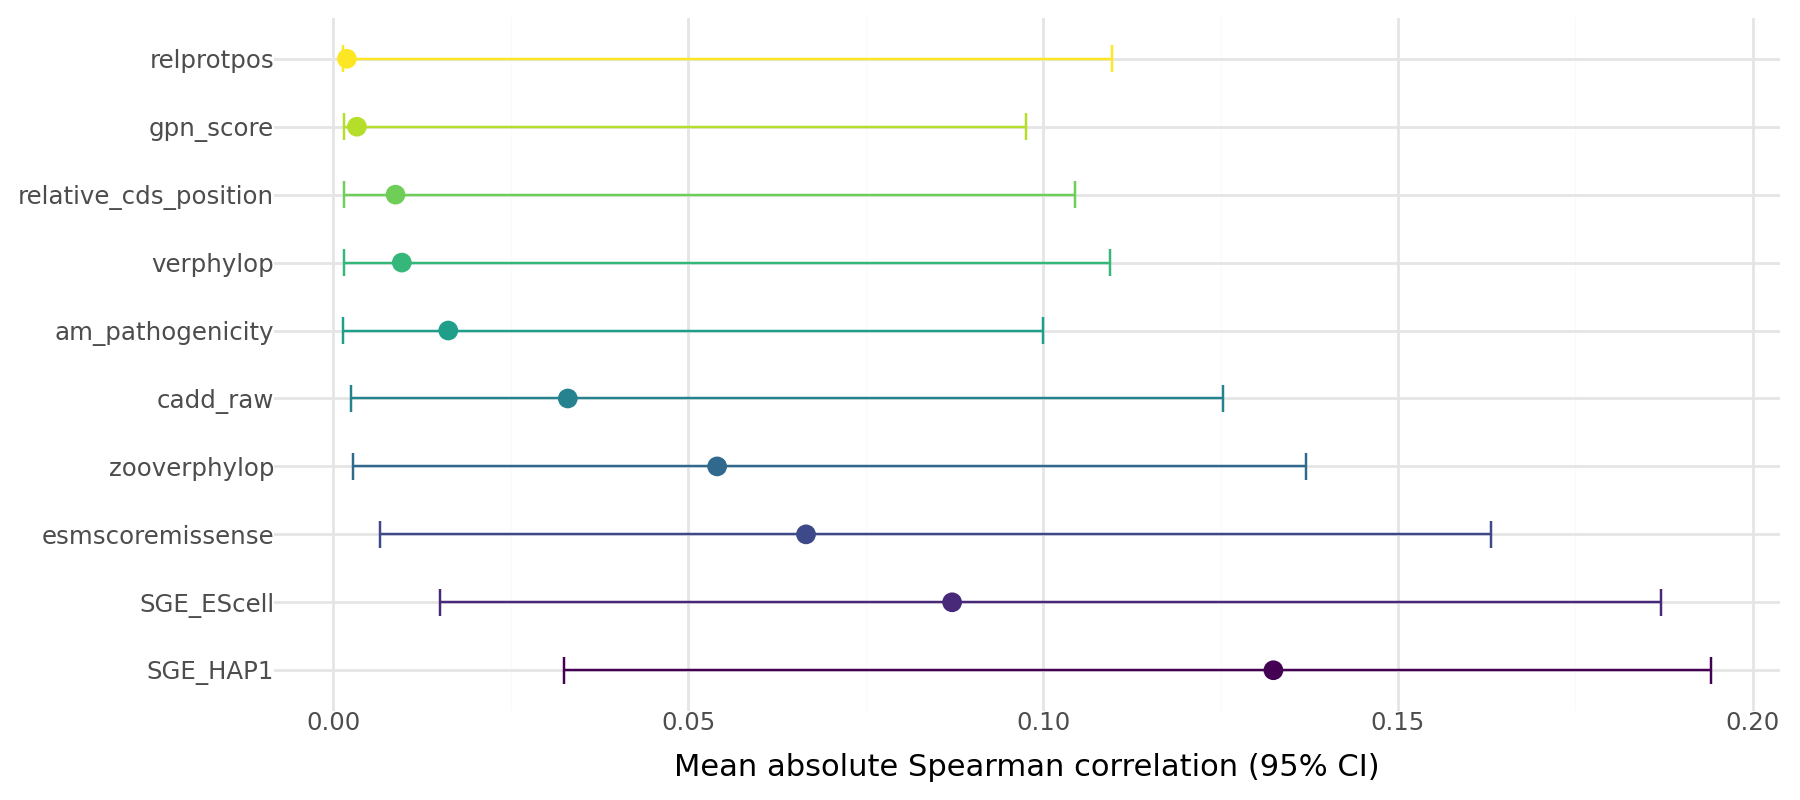

In [46]:
summary_df = final_corr_df.to_pandas()

# Ordering by mean correlation
summary_df['annotation'] = pd.Categorical(
    summary_df['annotation'],
    categories=summary_df.sort_values('abs_corr', ascending=False)['annotation'],
    ordered=True
)

summary_df['color_dms'] = summary_df['annotation'].str.startswith('HXK4').map({True: 'DMS', False: 'Other'})

# Plot
(
    ggplot(summary_df, aes(x='annotation', y='abs_corr', color='annotation')) +
    # geom_col(alpha=0.8) +
    geom_point(size=3) +
    geom_errorbar(aes(ymin='abs_corr_ci_lower', ymax='abs_corr_ci_upper'), width=0.4) +
    coord_flip() +
    theme_minimal() +
    labs(
        x='',
        y='Mean absolute Spearman correlation (95% CI)'
    ) +
    theme(
        figure_size=(9, 4),
        legend_position='none'
    )
)

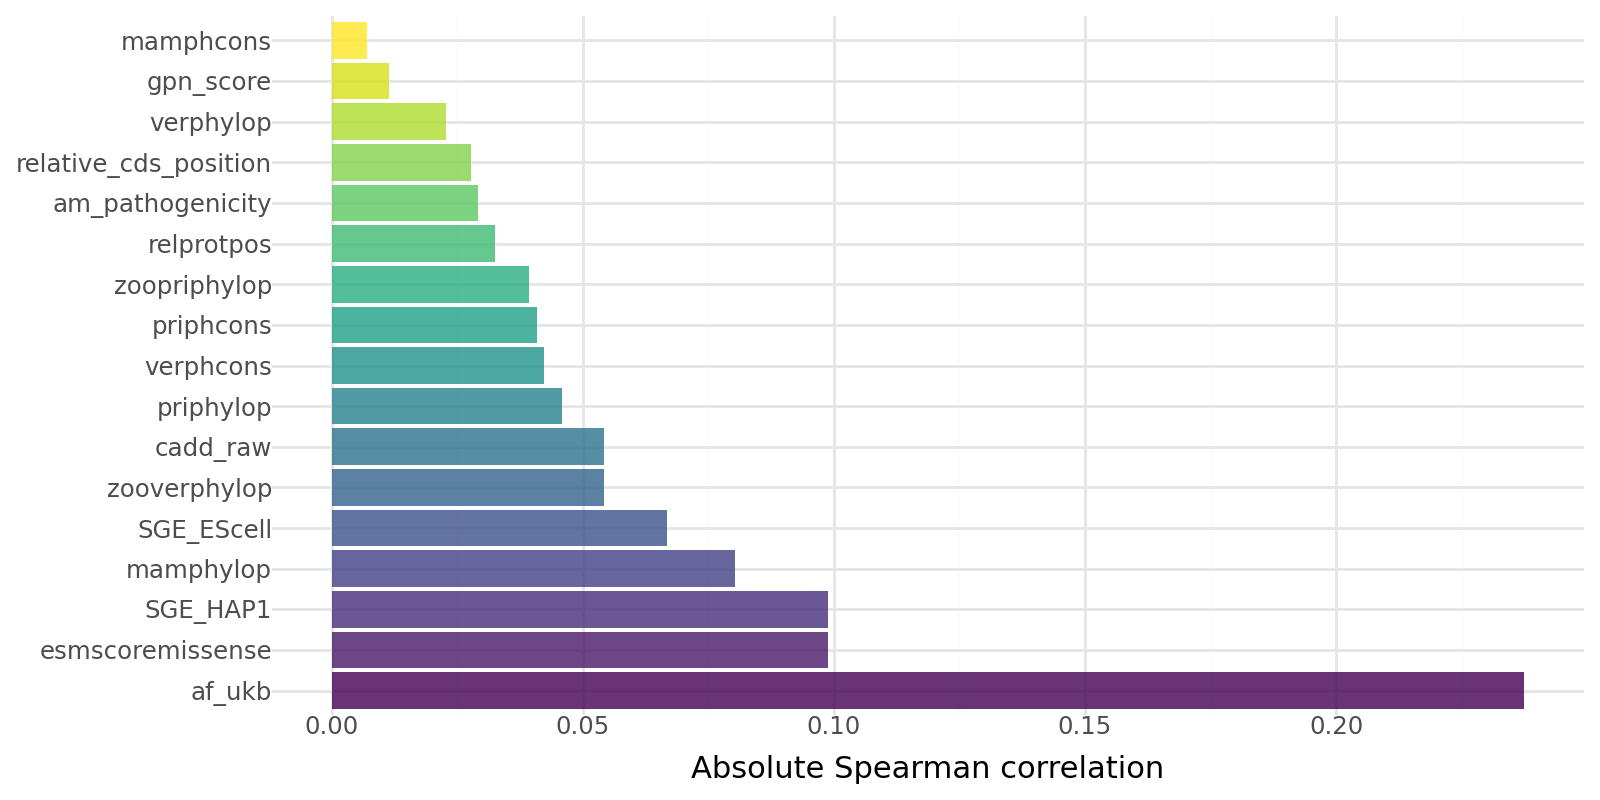

In [111]:
if all_vars:
    med_df = final_corr_df.drop_nans().group_by("annotation").agg([
        pl.col("abs_corr").median().alias("median_abs_corr")
    ])
else:
    med_df = final_corr_df.filter(~pl.col('annotation').str.contains('_allvars')).drop_nans().group_by("annotation").agg([
        pl.col("abs_corr").median().alias("median_abs_corr")
    ])

corr_pd = med_df.join(final_corr_df, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# Plot
(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_bar(stat='identity', alpha=0.8) +
    theme_minimal() +
    coord_flip() +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 4),
        legend_position='none'
    )
)

### Scatter plot

In [ ]:
def plot_correlation(plot_df, phenotype, gene_id, annotation, method='spearman'):
    # Filter and add ranks
    df_filtered = plot_df.filter(
        (pl.col('phenotype') == phenotype) &
        (pl.col('region') == gene_id) &
        (pl.col('annotation') == annotation)
    ).with_columns([
        pl.col('score').rank().alias('score_rank'),
        pl.col('mean_pheno_value').rank().alias('pheno_rank')
    ])

    # Determine columns to correlate and plot
    if method.lower() == 'spearman':
        x_col, y_col = 'score_rank', 'pheno_rank'
    elif method.lower() == 'pearson':
        x_col, y_col = 'score', 'mean_pheno_value'
    else:  # Pearson
        sys.exit(f"Unrecognized method. Use 'spearman' or 'pearson'.")

    # Compute correlation using Polars
    corr = df_filtered.select([pl.corr(x_col, y_col, method='pearson')]).to_numpy()[0, 0]

    corr_text = f"{method.title()} r = {corr:.2f}"

    # Build plot
    rc_plot = (
        ggplot(df_filtered.to_pandas(), aes(x=x_col, y=y_col)) +
        geom_point(alpha=0.25) +
        geom_smooth(method='lm', se=True, color='darkred') +
        theme_minimal() +
        labs(
            x=f"{annotation} {'rank' if method.lower()=='spearman' else ''}",
            y=f"{phenotype} residual {'rank' if method.lower()=='spearman' else ''}"
        ) +
        annotate(
            'text',
            x=df_filtered[x_col].min(),
            y=df_filtered[y_col].max(),
            label=corr_text,
            ha='left',
            va='top',
            size=12
        ) +
        theme(figure_size=(5, 4))
    )

    return rc_plot

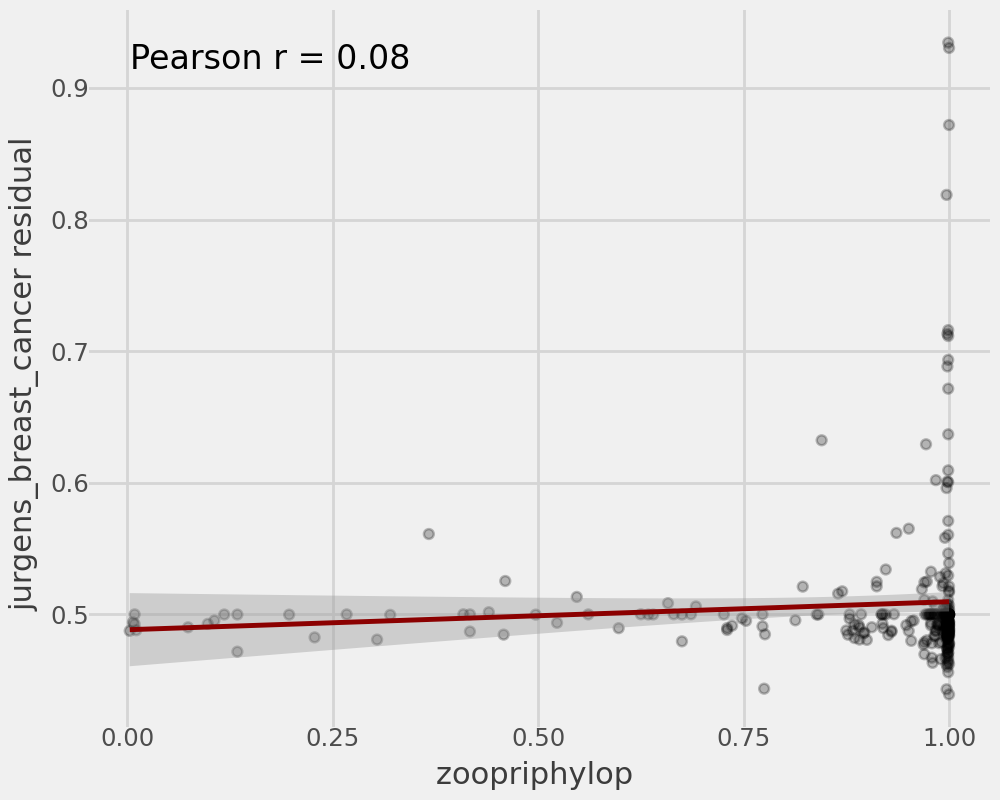

In [113]:
corr_method = 'pearson'
am_plot = plot_correlation(pheno_gis_df, gene_trait_df['phenotype'].item(), gene_trait_df['gene_id'].item(), 'zoopriphylop', method=corr_method)

am_plot

### Gene track plot

In [114]:
pheno_gis_df = pheno_gis_df.with_columns(
    pl.col('id').str.split(':').list.get(1).cast(pl.Int64).alias('pos')
)

pheno_df = pheno_gis_df[['pos', 'mean_pheno_value']].unique().sort('pos').to_pandas()
pheno_df

,pos,mean_pheno_value
0,32356428,0.492353
1,32356431,0.495157
2,32356440,0.486596
3,32356455,0.491936
4,32356458,0.494718
...,...,...
295,32396905,0.491256
296,32396907,0.499950
297,32396917,0.499954
298,32396938,0.499792


In [115]:
def plot_exon_compressed(
    pheno_df: pd.DataFrame,
    gtf_path: str,
    gene_id: str,
    gap: int = 20,
    exon_thickness: float = 0.1,
):
    """
    Plot phenotype values for variants compressed onto exons of a gene.
    """

    # --- Step 1: Read GTF, get exons for the gene ---
    gtf_cols = [
        "seqname", "source", "feature", "start", "end", "score",
        "strand", "frame", "attribute"
    ]
    gtf = pl.read_csv(
        gtf_path,
        separator="\t",
        has_header=False,
        comment_prefix="##",
        new_columns=gtf_cols
    )
    gtf = gtf.filter(pl.col("feature") == "exon")

    # Extract gene_id from the attribute field
    gtf = gtf.with_columns(
        pl.col("attribute")
        .str.extract(r'gene_id\s*"?([^";]+)"?')
        .str.split(".").list.get(0)
        .alias("gene_id")
    )
    exons = (
        gtf.filter(pl.col("gene_id") == gene_id)
        .select(["start", "end"])
        .to_pandas()
        .sort_values("start")
        .reset_index(drop=True)
    )

    if exons.empty:
        raise ValueError(f"No exons found for gene {gene_id}")

    # --- Step 2: Keep only exons that overlap with variant positions ---
    variant_positions = pheno_df["pos"].values
    exons = exons[
        exons.apply(
            lambda row: ((variant_positions >= row["start"]) & (variant_positions <= row["end"])).any(),
            axis=1,
        )
    ].reset_index(drop=True)

    if exons.empty:
        raise ValueError(f"No exons overlap with variants for gene {gene_id}")

    # --- Step 3: Build compressed coordinate mapping ---
    compressed_map = []
    current_pos = 0

    for _, row in exons.iterrows():
        length = row["end"] - row["start"] + 1
        compressed_map.append({
            "genomic_start": row["start"],
            "genomic_end": row["end"],
            "compressed_start": current_pos,
            "compressed_end": current_pos + length - 1
        })
        current_pos += length + gap

    map_df = pd.DataFrame(compressed_map)

    # --- Step 4: Map variant positions ---
    def map_pos(pos):
        for _, row in map_df.iterrows():
            if row.genomic_start <= pos <= row.genomic_end:
                return row.compressed_start + (pos - row.genomic_start)
        return None

    pheno_df = pheno_df.copy()
    pheno_df["compressed_pos"] = pheno_df["pos"].apply(map_pos)
    pheno_df = pheno_df.dropna(subset=["compressed_pos"])

    # --- Step 5: Build exon rectangles for shading ---
    exon_rects = map_df.assign(
        ymin=-exon_thickness / 2,
        ymax=exon_thickness / 2
    ).rename(columns={"compressed_start": "xmin", "compressed_end": "xmax"})

    return pheno_df, exon_rects

In [116]:
gene_id=gene_trait_df['gene_id'].item()
phenotype=gene_trait_df['phenotype'].item()

pheno_df, exon_rects = plot_exon_compressed(
    pheno_df=pheno_df,
    gtf_path='/home/dnanexus/data_dir/gencode.v48.annotation.gtf.gz',
    gene_id=gene_id,
    gap=5,
    exon_thickness=0.4,
)


plot = (
    ggplot(pheno_df, aes(x="compressed_pos", y="mean_pheno_value"))
    # + geom_line()
    + geom_segment(aes(x="compressed_pos", xend="compressed_pos", y=0, yend="mean_pheno_value"))
    + geom_rect(
        data=exon_rects,
        mapping=aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
        inherit_aes=False,
        alpha=0.2,
        fill="gray"
    )
    + theme_minimal()
    + theme(figure_size=(15, 4), legend_position="right")
    + labs(x="Exons (compressed)", y=f"{phenotype} residual")
)
plot

FileNotFoundError: No such file or directory (os error 2): /home/dnanexus/data_dir/gencode.v48.annotation.gtf.gz